In [15]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from numpy.fft import fft2, fftshift, ifft2, ifftshift
from scipy.ndimage import median_filter, uniform_filter, maximum_filter, minimum_filter
import cv2

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

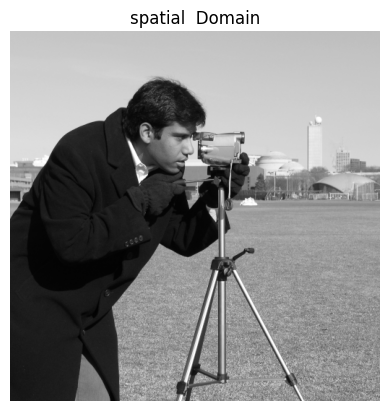

In [6]:
image = data.camera()
plt.imshow(image,cmap='gray')
plt.title("spatial  Domain" )
plt.axis('off')

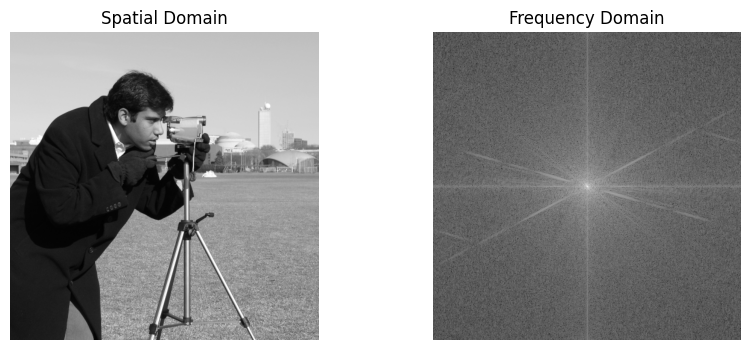

In [7]:
dft = fft2(image)
dft_shifted = fftshift(dft) #For complex numbers → it computes the magnitude using root square
magnitude_spectrum = 20 * np.log(np.abs(dft_shifted) + 1)

# Show results
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title("Spatial Domain")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title("Frequency Domain")
plt.axis('off')

plt.show()


In [25]:
dft.shape

(512, 512)

In [8]:
rows, cols = image.shape
crow, ccol = rows // 2, cols // 2

lpf = np.zeros((rows, cols), dtype=np.uint8)
r = 50  # radius of low-pass filter

for i in range(rows):
    for j in range(cols):
        if (i - crow)**2 + (j - ccol)**2 <= r**2:
            lpf[i, j] = 1

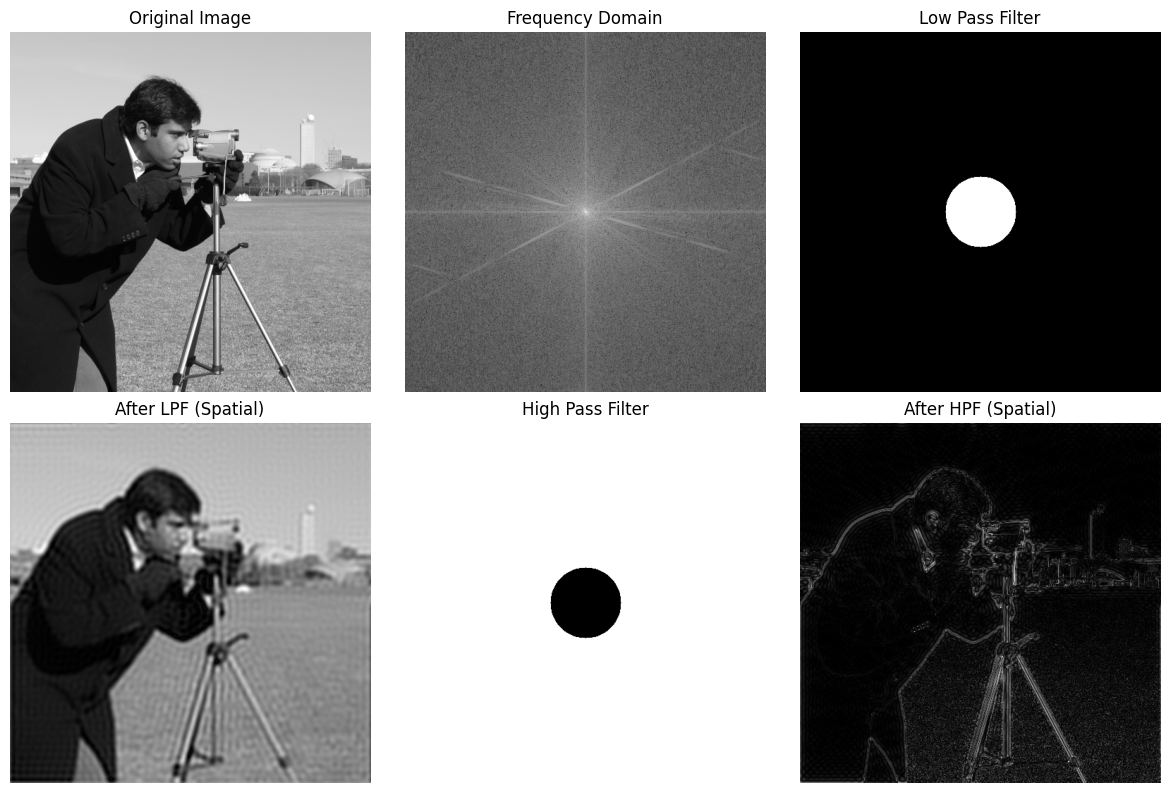

In [ ]:

lpf_dft = dft_shifted * lpf
hpf = 1 - lpf

# Apply HPF
hpf_dft = dft_shifted * hpf

lpf_ishift = ifftshift(lpf_dft)
lpf_img = np.abs(ifft2(lpf_ishift))

# HPF result
hpf_ishift = ifftshift(hpf_dft)
hpf_img = np.abs(ifft2(hpf_ishift))


plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title("Frequency Domain")
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(lpf, cmap='gray')
plt.title("Low Pass Filter")
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(lpf_img, cmap='gray')
plt.title("After LPF (Spatial)")
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(hpf, cmap='gray')
plt.title("High Pass Filter")
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(hpf_img, cmap='gray')
plt.title("After HPF (Spatial)")
plt.axis('off')

plt.tight_layout()
plt.show()


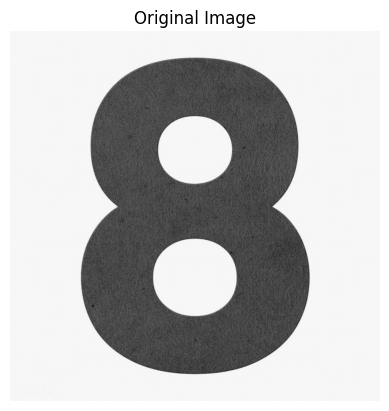

In [12]:
img = cv2.imread('eight.jpg')
img2 = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.imshow(img2,cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.show()

In [19]:
mean = 0
sigma = 300

gaussian = np.random.normal(mean, sigma, img2.shape)#This creates a noise matrix same size as image
noisy_img = img2 + gaussian

noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)

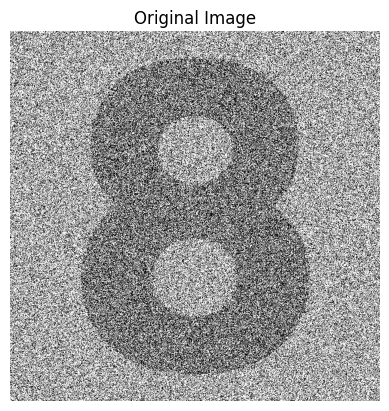

In [20]:
plt.imshow(noisy_img, cmap='gray')
plt.title("Original Image")
plt.axis("off")
plt.show()

In [17]:
def adaptive_median(img, max_size=7):
    img = img.copy()
    h, w = img.shape

    padded = np.pad(img, max_size//2, mode='edge')# padding based on the max size of the filter

    for i in range(h):
        for j in range(w):
            size = 3# the smallest filter size
            z_med = None
            while size <= max_size:
                r = size // 2
                window = padded[i:i+size, j:j+size]

                z_min = np.min(window)
                z_max = np.max(window)
                z_med = np.median(window)
                z_xy = padded[i+r, j+r]

                if z_min < z_med < z_max:
                    break

                size += 2 # increase the filter size by odd numbers to maintain a center pixel
            
            r = min(size, max_size) // 2
            z_xy = padded[i+r, j+r]  # safe center


            if z_min < z_xy < z_max:
                img[i, j] = z_xy
            else:
                img[i, j] = z_med
    return img


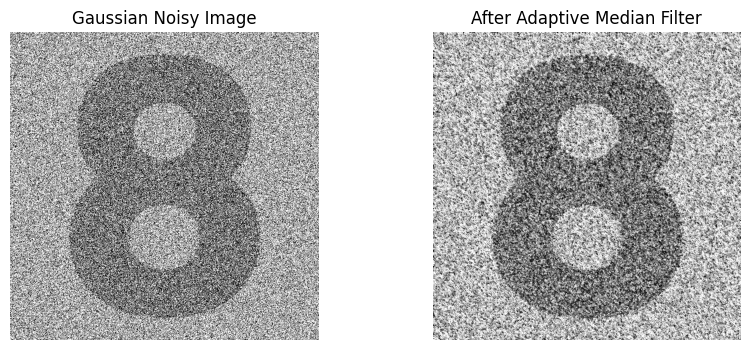

In [21]:
adaptive_result = adaptive_median(noisy_img)
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(noisy_img, cmap='gray')
plt.title("Gaussian Noisy Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(adaptive_result, cmap='gray')
plt.title("After Adaptive Median Filter")
plt.axis('off')

plt.show()


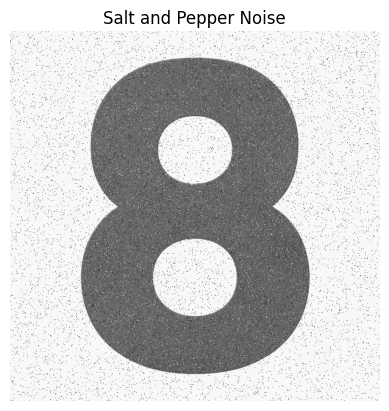

In [23]:
import numpy as np

def add_salt_pepper_noise(image, prob=0.02):
    noisy = image.copy()
    
    # Salt (white pixels)
    salt = np.random.rand(*image.shape) < (prob)
    noisy[salt] = 255

    # Pepper (black pixels)
    pepper = np.random.rand(*image.shape) < (prob)
    noisy[pepper] = 0

    return noisy
salt_pepper_img = add_salt_pepper_noise(img2) 
plt.imshow(salt_pepper_img, cmap='gray')
plt.title("Salt and Pepper Noise")
plt.axis("off")
plt.show()  

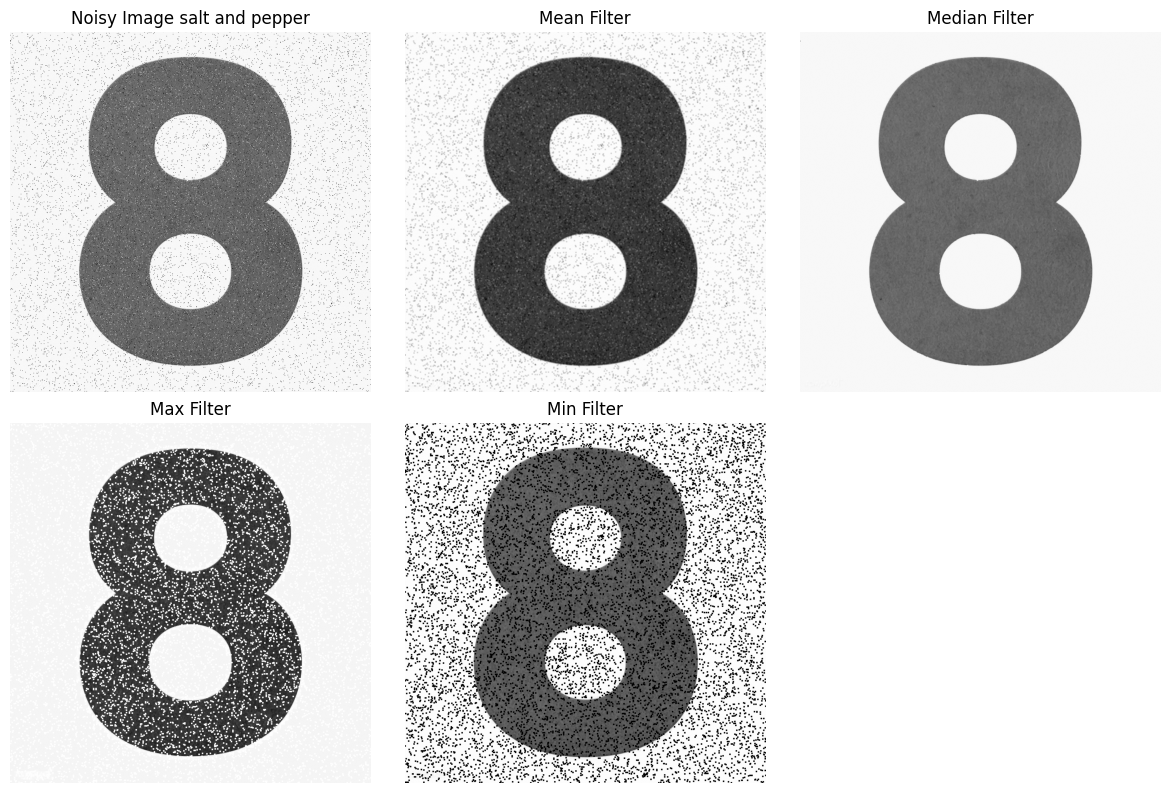

In [24]:
mean_filtered = uniform_filter(salt_pepper_img, size=3)
median_filtered = median_filter(salt_pepper_img, size=3)
max_filtered = maximum_filter(salt_pepper_img, size=3)
min_filtered = minimum_filter(salt_pepper_img, size=3)
plt.figure(figsize=(12,8))

titles = [
    "Noisy Image salt and pepper",
    "Mean Filter",
    "Median Filter",
    "Max Filter",
    "Min Filter"
]

images = [
    salt_pepper_img,
    mean_filtered,
    median_filtered,
    max_filtered,
    min_filtered
]

for i in range(5):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.tight_layout()
plt.show()
